# First passage under censoring

Compare survival and restricted mean at a common observation cutoff. At arrival=removal the unrestricted mean is infinite, despite almost-sure eventual depletion.

Synthetic data only. All settings and random seeds are specified below.

In [1]:
from pathlib import Path
import sys, json, platform
import numpy as np
import pandas as pd
# Embed figures in saved notebook outputs, even when MPLBACKEND=Agg.
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT / "src"))
OUT = ROOT / "results" / "synthetic" / "queues"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True, "grid.alpha": .2})
print({"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__})


{'python': '3.12.0', 'numpy': '1.26.0', 'pandas': '2.1.1'}


,arrival,cutoff,samples,depleted,censored,survival,survival_low,survival_high,restricted_mean,restricted_se,completed_only_mean,reference_restricted_mean
0,0.0,100.0,10000,10000,0,0.0000,0.000000,0.001597,1.502542,0.008629,1.502542,1.500000
1,1.0,100.0,10000,10000,0,0.0000,0.000000,0.001597,3.005891,0.030812,3.005891,3.000000
2,1.9,100.0,10000,9318,682,0.0682,0.058791,0.078989,16.874367,0.278593,10.790263,16.613232
3,2.0,100.0,10000,8755,1245,0.1245,0.111891,0.138309,22.111196,0.336829,11.035061,21.773732


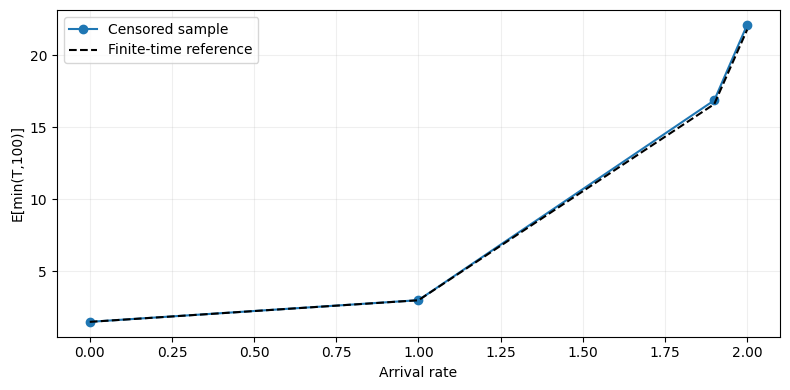

In [2]:
from queue_models.queue_depletion import QueueConfig,simulate,summarize,reference
rows=[]
for arrival in (0.,1.,1.9,2.):
    config=QueueConfig(3,arrival,2.)
    sample=simulate(config,horizon=100.,samples=10000,seed=310)
    summary=summarize(sample,100.)
    ref=reference(config,[100.])[0]
    rows.append(dict(arrival=arrival,**summary,reference_restricted_mean=ref["restricted_mean"]))
table=pd.DataFrame(rows);display(table)
table.to_csv(OUT/"queue_depletion.csv",index=False)
plt.plot(table.arrival,table.restricted_mean,"o-",label="Censored sample")
plt.plot(table.arrival,table.reference_restricted_mean,"k--",label="Finite-time reference")
plt.xlabel("Arrival rate");plt.ylabel("E[min(T,100)]");plt.legend()
plt.tight_layout();plt.savefig(OUT/"queue_depletion.png",dpi=140);plt.show()


## Interpretation

Compare the displayed model reference with the simulation. Finite-sample agreement is an implementation check, not evidence of real-market calibration. See [assumptions](../../../docs/model_assumptions.md) and [limitations](../../../docs/validation_and_limitations.md).